# 07B. Ejercicio: Regresión Lineal — Advertising
### Semana 09 | Predictive Analytics

**Caso de negocio:** Un gerente de marketing quiere saber:
**¿Cuánto invertir en TV, Radio y Newspaper para maximizar las ventas?**

Dataset: `Advertising.csv` — presupuesto de publicidad (en miles $) y ventas.

**Aplica lo aprendido en 07A:**
- Exploración visual
- Pipeline con StandardScaler + LinearRegression
- Métricas: RMSE, MAE, R², R² ajustado
- Interpretación de coeficientes

## Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

pd.options.display.float_format = '{:.3f}'.format

In [ ]:
# Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

import os
ruta = r'/content/drive/MyDrive/LABS/Semana09'
os.chdir(ruta)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Paso 1: Cargar y explorar el dataset
Carga `Advertising.csv` en un DataFrame y muestra sus dimensiones y primeras filas.

In [ ]:
df = pd.read_csv("Advertising.csv")

print(df.shape)
df.head()

(200, 4)


,TV,Radio,Newspaper,Sales
0,230.100,37.800,69.200,2210
1,44.500,39.300,45.100,1040
2,17.200,45.900,69.300,930
3,151.500,41.300,58.500,1850
4,180.800,10.800,58.400,1290


### Explorar la estructura
Muestra la cantidad de filas y columnas, y un resumen estadístico con `.describe()`.

In [ ]:
print(df.shape)
df.describe()


(200, 4)


,TV,Radio,Newspaper,Sales
count,200.000,200.000,200.000,200.000
mean,147.042,23.264,30.554,1402.250
std,85.854,14.847,21.779,521.746
min,0.700,0.000,0.300,160.000
25%,74.375,9.975,12.750,1037.500
50%,149.750,22.900,25.750,1290.000
75%,218.825,36.525,45.100,1740.000
max,296.400,49.600,114.000,2700.000


## Paso 2: Visualización
Crea 3 gráficos de dispersión que muestren la relación entre **Sales** y
cada presupuesto: TV, Radio y Newspaper.

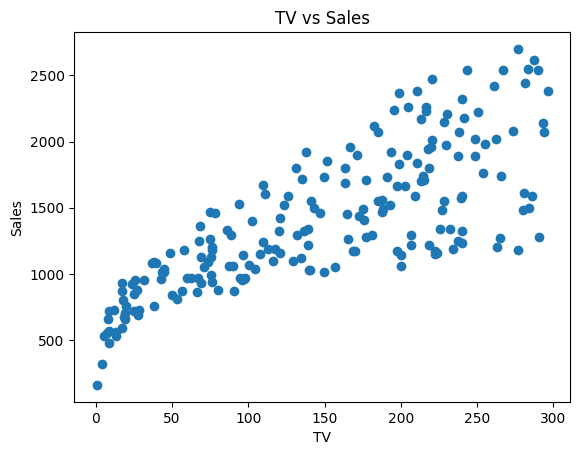

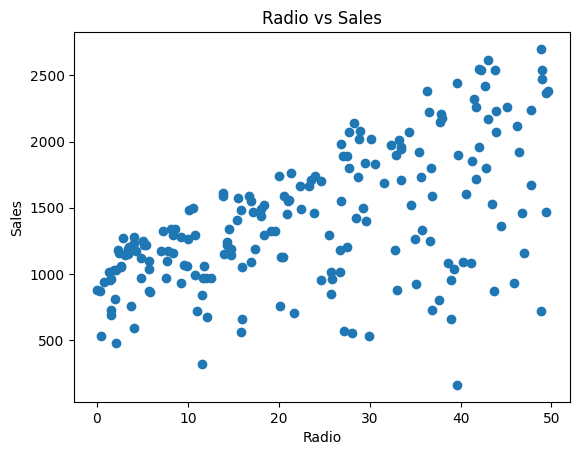

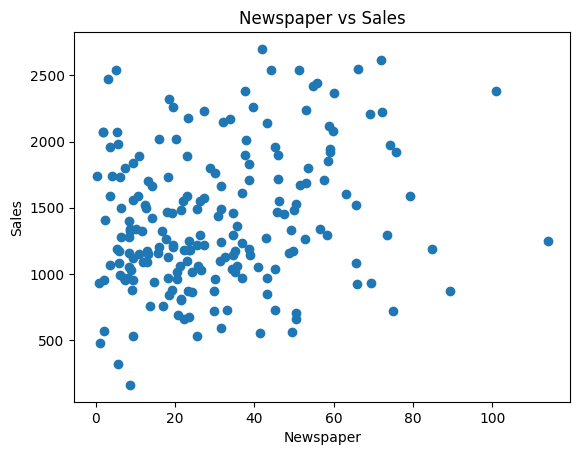

In [ ]:
plt.scatter(df["TV"], df["Sales"])
plt.xlabel("TV")
plt.ylabel("Sales")
plt.title("TV vs Sales")
plt.show()

plt.scatter(df["Radio"], df["Sales"])
plt.xlabel("Radio")
plt.ylabel("Sales")
plt.title("Radio vs Sales")
plt.show()

plt.scatter(df["Newspaper"], df["Sales"])
plt.xlabel("Newspaper")
plt.ylabel("Sales")
plt.title("Newspaper vs Sales")
plt.show()


**Pregunta:** ¿Cuál variable parece tener la relación más fuerte con Sales? ¿Cuál parece no aportar mucho?

La variable TV parece tener la relación más fuerte con Sales.
Radio también muestra relación positiva.
Newspaper parece aportar menos porque los puntos están más dispersos.

## Paso 3: Construir Pipeline y evaluar
1. Importar `LinearRegression`, `train_test_split`, `Pipeline`, `StandardScaler`
2. Separar X (TV, Radio, Newspaper) e y (Sales)
3. Hacer train_test_split (test_size=0.2, random_state=42)
4. Crear Pipeline con StandardScaler + LinearRegression
5. Entrenar y evaluar con RMSE, MAE, R²

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

X = df[["TV", "Radio", "Newspaper"]]
y = df["Sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("modelo", LinearRegression())
])

pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

RMSE: 178.1599661533451
MAE: 146.07567168117603
R2: 0.8994380241009119


## Paso 4: R² Ajustado

El **R² ajustado** penaliza por agregar variables que no aportan.
Si una variable no mejora el modelo, R² ajustado será menor que R².

Fórmula: `R²_adj = 1 - (1 - R²) * (n - 1) / (n - p - 1)`
donde n = muestras, p = predictores.

In [ ]:
n = X_test.shape[0]
p = X_test.shape[1]
r2_adj = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f'R²:          {r2:.4f}')
print(f'R² ajustado: {r2_adj:.4f}')

R²:          0.8994
R² ajustado: 0.8911


## Paso 5: Coeficientes — ¿Dónde invertir?
Extrae los coeficientes del modelo dentro del Pipeline y muestra cuáles
variables tienen mayor impacto en las ventas.

In [ ]:
coeficientes = pipe.named_steps["modelo"].coef_

df_coef = pd.DataFrame({
    "variable": X.columns,
    "coeficiente": coeficientes
})

df_coef

df_coef.sort_values("coeficiente", ascending=False)

,variable,coeficiente
0,TV,376.420
1,Radio,279.231
2,Newspaper,5.598


## Encuentra el error

Un compañero escribió este código para predecir ventas. **¿Qué está mal?**

```python
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_ads)  # Escala TODO
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_ads)
modelo = LinearRegression()
modelo.fit(X_train, y_train)
```

El error es que escala todo X antes de hacer train_test_split.
Eso genera fuga de datos porque el scaler aprende información del conjunto completo.
Lo correcto es separar primero train y test, y luego usar Pipeline para que el escalado se ajuste solo con X_train.

## Paso 6: Conclusiones
Elabora dos conclusiones basándote en los resultados obtenidos:
1. ¿Qué tan bueno es el modelo para predecir ventas?
2. ¿En qué canal(es) de publicidad debería invertir más el gerente de marketing?

In [ ]:
print("Conclusión 1:")
print("El modelo tiene buen desempeño si el R2 es alto, porque explica gran parte de la variación de Sales.")

print("Conclusión 2:")
print("El gerente debería invertir más en TV y Radio, ya que son las variables con mayor relación e impacto sobre Sales.")


Conclusión 1:
El modelo tiene buen desempeño si el R2 es alto, porque explica gran parte de la variación de Sales.
Conclusión 2:
El gerente debería invertir más en TV y Radio, ya que son las variables con mayor relación e impacto sobre Sales.
